In [68]:
#pip install --upgrade scikit-learn

## Q.1 Data Loading and ETL using Dplyr

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [73]:
## Q.1.1 Q.1.2

In [4]:
df = pd.read_csv('wine_quality_red.csv',sep=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [74]:
## Q1.2

In [5]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [72]:
## Q.1.3

In [7]:
df = df.rename(columns={"fixed acidity": "FixedAcidity"})
df.columns

Index(['FixedAcidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [76]:
## 1.4,5

In [8]:
df['AcidityRatio'] = df['FixedAcidity']/df['volatile acidity']
df.head()

,FixedAcidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,AcidityRatio
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,10.571429
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,8.863636
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,10.263158
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,40.000000
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,10.571429


In [ ]:
## 1.6

In [9]:
alco_greater_11 = df[df['alcohol']>11]
alco_greater_11

,FixedAcidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,AcidityRatio
45,4.6,0.52,0.15,2.1,0.054,8.0,65.0,0.99340,3.90,0.56,13.1,4,8.846154
95,4.7,0.60,0.17,2.3,0.058,17.0,106.0,0.99320,3.85,0.60,12.9,6,7.833333
131,5.6,0.50,0.09,2.3,0.049,17.0,99.0,0.99370,3.63,0.63,13.0,5,11.200000
132,5.6,0.50,0.09,2.3,0.049,17.0,99.0,0.99370,3.63,0.63,13.0,5,11.200000
142,5.2,0.34,0.00,1.8,0.050,27.0,63.0,0.99160,3.68,0.79,14.0,6,15.294118
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1586,7.5,0.31,0.41,2.4,0.065,34.0,60.0,0.99492,3.34,0.85,11.4,6,24.193548
1588,7.2,0.66,0.33,2.5,0.068,34.0,102.0,0.99414,3.27,0.78,12.8,6,10.909091
1590,6.3,0.55,0.15,1.8,0.077,26.0,35.0,0.99314,3.32,0.82,11.6,6,11.454545
1591,5.4,0.74,0.09,1.7,0.089,16.0,26.0,0.99402,3.67,0.56,11.6,6,7.297297


In [12]:
## 1.7

In [11]:
df.groupby('quality')[['alcohol','sulphates']].mean()

,alcohol,sulphates
quality,,
3,9.955000,0.570000
4,10.265094,0.596415
5,9.899706,0.620969
6,10.629519,0.675329
7,11.465913,0.741256
8,12.094444,0.767778


## Q2. Correlation covariance and outlier analysis

In [15]:
## Q2.1

In [16]:
covariance_value = df['alcohol'].cov(df['sulphates'])
covariance_value

0.01690677723326765

In [18]:
## Q2.2

In [17]:
correlation_value = df['alcohol'].corr(df['quality'])
correlation_value

0.4761663240011355

In [26]:
## Q2.3

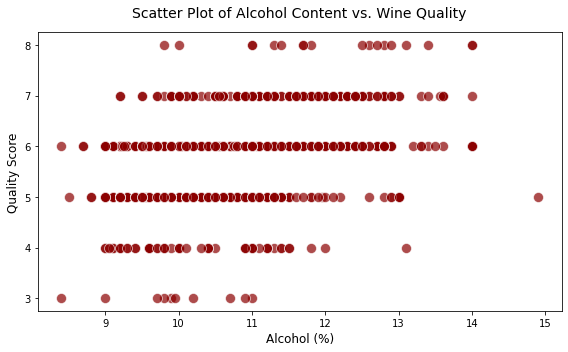

In [25]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, x="alcohol", y="quality", color="darkred", s=100, alpha=0.7
)
plt.title("Scatter Plot of Alcohol Content vs. Wine Quality", fontsize=14, pad=15)
plt.xlabel("Alcohol (%)", fontsize=12)
plt.ylabel("Quality Score", fontsize=12)
plt.tight_layout()
plt.show()

In [77]:
## Q2.4

In [30]:
q1 = df["alcohol"].quantile(0.25)
q3 = df["alcohol"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print(f"Q1 (25th percentile): {q1:.2f}")
print(f"Q3 (75th percentile): {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")
print("-" * 50)

outliers = df[(df["alcohol"] < lower_bound) | (df["alcohol"] > upper_bound)]
clean_df = df[(df["alcohol"] >= lower_bound) & (df["alcohol"] <= upper_bound)]

print(f"Total outliers detected: {len(outliers)}")
if len(outliers) > 0:
    print("\nOutlier Records:")
    print(outliers[["alcohol", "quality"]])

Q1 (25th percentile): 9.50
Q3 (75th percentile): 11.10
IQR: 1.60
Lower Bound: 7.10
Upper Bound: 13.50
--------------------------------------------------
Total outliers detected: 13

Outlier Records:
        alcohol  quality
142   14.000000        6
144   14.000000        6
467   14.000000        6
588   14.000000        8
652   14.900000        5
821   14.000000        7
1114  13.600000        6
1132  13.600000        7
1228  13.600000        7
1269  14.000000        8
1270  14.000000        6
1475  13.566667        7
1477  13.600000        7


In [31]:
## Q2.5

In [32]:
q1 = df["alcohol"].quantile(0.25)
q3 = df["alcohol"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df_cleaned = df[(df["alcohol"] >= lower_bound) & (df["alcohol"] <= upper_bound)]

original_corr = df["alcohol"].corr(df["sulphates"])
new_corr = df_cleaned["alcohol"].corr(df_cleaned["sulphates"])

print(f"Original Correlation (with outliers): {original_corr:.4f}")
print(f"New Correlation (outliers removed):   {new_corr:.4f}")

Original Correlation (with outliers): 0.0936
New Correlation (outliers removed):   0.0761


## Q3 Independent Two Sample t-Test

In [33]:
## Q3.1
group_A = df[df["quality"] <= 5]["alcohol"]
group_B = df[df["quality"] > 5]["alcohol"]

In [34]:
# 2. Compare the mean alcohol content
mean_A = group_A.mean()
mean_B = group_B.mean()

print(f"Group A (Quality <= 5) Mean Alcohol: {mean_A:.2f}%")
print(f"Group B (Quality > 5) Mean Alcohol:  {mean_B:.2f}%")
print("-" * 60)

Group A (Quality <= 5) Mean Alcohol: 9.93%
Group B (Quality > 5) Mean Alcohol:  10.86%
------------------------------------------------------------


In [37]:
# 3. Perform an Independent Two-Sample T-test
# equal_var=False runs Welch's T-test, which doesn't assume equal variances
t_stat, p_value = stats.ttest_ind(group_A, group_B, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.4f}")
print("-" * 60)

T-statistic: -19.7822
P-value:     0.0000
------------------------------------------------------------


In [38]:
# 4. Interpret the results
alpha = 0.05  # 5% Significance level
if p_value < alpha:
    print(
        "Conclusion: Reject the null hypothesis.\nThe difference in mean alcohol content between low-quality (<=5) and high-quality (>5) wines is statistically significant."
    )
else:
    print(
        "Conclusion: Fail to reject the null hypothesis.\nThere is no statistically significant difference in mean alcohol content between the two groups."
    )

Conclusion: Reject the null hypothesis.
The difference in mean alcohol content between low-quality (<=5) and high-quality (>5) wines is statistically significant.


## Q4. Mann-Whitney U-Test

In [41]:
# 1. Separate into two groups based on Quality
group_A = df[df["quality"] <= 5]["alcohol"]
group_B = df[df["quality"] > 5]["alcohol"]

In [43]:
# 2. Calculate Group Statistics
stats_A = group_A.agg(["count", "mean", "median"])
stats_B = group_B.agg(["count", "mean", "median"])
print("=== 1. Group Statistics ===")
print(
    f"Group A (Quality <= 5): Count = {stats_A['count']:.0f}, Mean = {stats_A['mean']:.2f}, Median = {stats_A['median']:.2f}"
)
print(
    f"Group B (Quality > 5) : Count = {stats_B['count']:.0f}, Mean = {stats_B['mean']:.2f}, Median = {stats_B['median']:.2f}"
)
print("-" * 60)

=== 1. Group Statistics ===
Group A (Quality <= 5): Count = 744, Mean = 9.93, Median = 9.70
Group B (Quality > 5) : Count = 855, Mean = 10.86, Median = 10.80
------------------------------------------------------------


In [47]:
# 3. Perform Mann-Whitney U Test
# alternative='two-sided' tests for any directional difference between distributions
u_stat, p_value = stats.mannwhitneyu(group_A, group_B, alternative="two-sided")

print("=== 2. Test Results ===")
print(f"Mann-Whitney U statistic: {u_stat:.4f}")
print(f"p-value:                  {p_value:.4f}")
print("-" * 60)

=== 2. Test Results ===
Mann-Whitney U statistic: 154807.0000
p-value:                  0.0000
------------------------------------------------------------


In [46]:
# 4. Interpretation
print("=== 3. Interpretation ===")
alpha = 0.05
if p_value < alpha:
    print(
        f"Result: Significant (p < {alpha}).\nConclusion: Reject the null hypothesis. There is a statistically significant difference in the distribution of alcohol levels between lower quality wines (<= 5) and higher quality wines (> 5)."
    )
else:
    print(
        f"Result: Not Significant (p >= {alpha}).\nConclusion: Fail to reject the null hypothesis. There is no statistically significant difference in the distribution of alcohol levels between the two quality groups."
    )

=== 3. Interpretation ===
Result: Significant (p < 0.05).
Conclusion: Reject the null hypothesis. There is a statistically significant difference in the distribution of alcohol levels between lower quality wines (<= 5) and higher quality wines (> 5).


## Q5 Predictive Modeling - Linear Regression

In [48]:
# Define Features (X) and Target (y)
features = ["alcohol", "sulphates", "volatile acidity"]
X = df[features]
y = df["quality"]

In [52]:
# 2. Split the dataset into training (70%) and testing (30%) sets
# random_state ensures reproducible results
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)
print(f"Total dataset shape: {X.shape}")
print(f"Training set shape:  {X_train.shape} (70%)")
print(f"Testing set shape:   {X_test.shape} (30%)\n")

Total dataset shape: (1599, 3)
Training set shape:  (1119, 3) (70%)
Testing set shape:   (480, 3) (30%)



In [55]:
# 3. Build a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [57]:
model.coef_, model.intercept_

(array([ 0.32419811,  0.5877969 , -1.16606272]), 2.479116081163844)

In [59]:
# 4. Predict quality values on the test dataset
y_pred = model.predict(X_test)

print("=== 2. Predicted Quality Values on Test Dataset ===")
pred_df = pd.DataFrame(
    {"Actual Quality": y_test.values, "Predicted Quality": y_pred}
)
print(pred_df)
print("-" * 60)

=== 2. Predicted Quality Values on Test Dataset ===
     Actual Quality  Predicted Quality
0                 6           5.326369
1                 5           5.258109
2                 6           5.483456
3                 5           5.437279
4                 6           5.731905
..              ...                ...
475               7           5.543455
476               8           6.019241
477               6           5.731905
478               7           6.097908
479               4           5.443720

[480 rows x 2 columns]
------------------------------------------------------------


In [67]:
# 5. Calculate RMSE (Root Mean Squared Error)
# Note: root_mean_squared_error is the standard function in scikit-learn >= 1.4
rmse = mean_squared_error(y_test, y_pred)

print("=== 3. Performance Metrics ===")
print(f"Mean Squared Error (RMSE): {rmse:.4f}")
print("-" * 60)

=== 3. Performance Metrics ===
Mean Squared Error (RMSE): 0.4286
------------------------------------------------------------
